# Meteorological Feature Overlap Analysis

**Comprehensive Analysis of MCS, AR, and ETC Interactions**

This notebook implements a scientifically robust framework for analyzing overlaps between:
- **MCS (Mesoscale Convective Systems)**: Smallest scale features
- **AR (Atmospheric Rivers)**: Medium scale features  
- **ETC (Extratropical Cyclones)**: Largest scale features

## Key Features:
- **Meteorologically-informed thresholds** respecting atmospheric scale hierarchy
- **Pair-based filtering** ensuring visual consistency
- **Vectorized overlap detection** for efficiency
- **Comprehensive visualization** of 2-way and 3-way interactions

## Threshold Design:
- **2-way overlaps**: MCS=20%, AR=10%, ETC=5%
- **3-way overlaps**: MCS=20%, AR=10%, ETC=0% (environmental context)

In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# LOAD DATA
# Update these paths as needed for your data location
# in_dir = '/global/cfs/cdirs/m1867/zfeng/PyFLEXTRKR/quicklook_dev/sample_data'
# root_dir = '/global/homes/f/feng045/program/hackathon/hk25-teams/hk25-Tracking'
# figdir = f'{root_dir}/figures'

source_name = "scream"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/allmasks/"
in_dir = f"{root_dir}/{source_name}_allmasks_hp8_v1.zarr"

figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/"
# figdir = "/pscratch/sd/w/wcmca1/hackathon/"
os.makedirs(figdir, exist_ok=True)

# Load the processed dataset
print(f"Loading data from: {in_dir}")

ds = xr.open_dataset(in_dir)
ds = ds.pipe(egh.attach_coords)
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/allmasks//scream_allmasks_hp8_v1.zarr


<xarray.Dataset> Size: 49GB
Dimensions:   (time: 3138, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ar_mask   (time, cell) int32 10GB ...
    etc_mask  (time, cell) int32 10GB ...
    mcs_mask  (time, cell) float64 20GB ...
    tc_mask   (time, cell) int32 10GB ...
Attributes: (12/37)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tb_threshold_core:            225.0
    tb_threshold_environment:     261.0
    tb_threshold_warmanvil:       261.0
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [ ]:
# tm = '2019-11-24T03'
# tm = '2019-11-26T06'
# tm = '2019-11-26T21'
# tm = '2019-11-27T06'
# tm = '2019-11-28T12'
tm = '2019-11-29T06'
# tm = '2019-11-30T09'
# tm = '2019-11-30T21'

# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

print(f"Dataset loaded successfully!")
print(f"Data variables: {list(_ds.data_vars)}")
print(f"Spatial dimensions: {_ds.dims}")

# Display basic statistics
n_mcs = len(np.unique(_ds.mcs_mask.values[_ds.mcs_mask.values > 0]))
n_ar = len(np.unique(_ds.ar_mask.values[_ds.ar_mask.values > 0]))
n_etc = len(np.unique(_ds.etc_mask.values[_ds.etc_mask.values > 0]))
n_tc = len(np.unique(_ds.tc_mask.values[_ds.tc_mask.values > 0]))

print(f"\nFeature counts:")
print(f"  MCS tracks: {n_mcs}")
print(f"  AR tracks: {n_ar}")
print(f"  ETC tracks: {n_etc}")
print(f"  TC tracks: {n_tc}")

Dataset loaded successfully!
Data variables: ['ar_mask', 'etc_mask', 'mcs_mask', 'tc_mask']
Spatial dimensions: FrozenMappingWarningOnValuesAccess({'cell': 786432})

Feature counts:
  MCS tracks: 115
  AR tracks: 7
  ETC tracks: 7
  TC tracks: 1


## Visualize all masks

In [4]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12, 
                          show_track_labels=True, track_fontsize=8):
    """
    Plot all 4 feature masks at a single time step with optional track labels.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    - show_track_labels: whether to show track ID labels for ETC and AR features (default True)
    - track_fontsize: font size for track labels (default 8)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add track labels for ETC and AR features if requested
    if show_track_labels:
        # Helper function for circular longitude averaging (handles dateline crossing)
        def circular_lon_mean(lon_values):
            """Calculate circular mean for longitude values to handle dateline crossing."""
            # Convert to radians
            lon_rad = np.deg2rad(lon_values)
            # Calculate circular mean using complex numbers
            mean_complex = np.mean(np.exp(1j * lon_rad))
            # Convert back to degrees and ensure 0-360 range
            mean_lon = np.rad2deg(np.angle(mean_complex))
            if mean_lon < 0:
                mean_lon += 360
            return mean_lon
        
        # Add ETC track labels (green)
        etc_tracks = np.unique(etc_mask.values[etc_mask.values > 0])
        for track_id in etc_tracks:
            track_pixels = (etc_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='green', ha='center', va='center')
        
        # Add AR track labels (darkorange)
        ar_tracks = np.unique(ar_mask.values[ar_mask.values > 0])
        for track_id in ar_tracks:
            track_pixels = (ar_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='darkorange', ha='center', va='center')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

Figure saved as /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_allmasks_20191126_2100.png


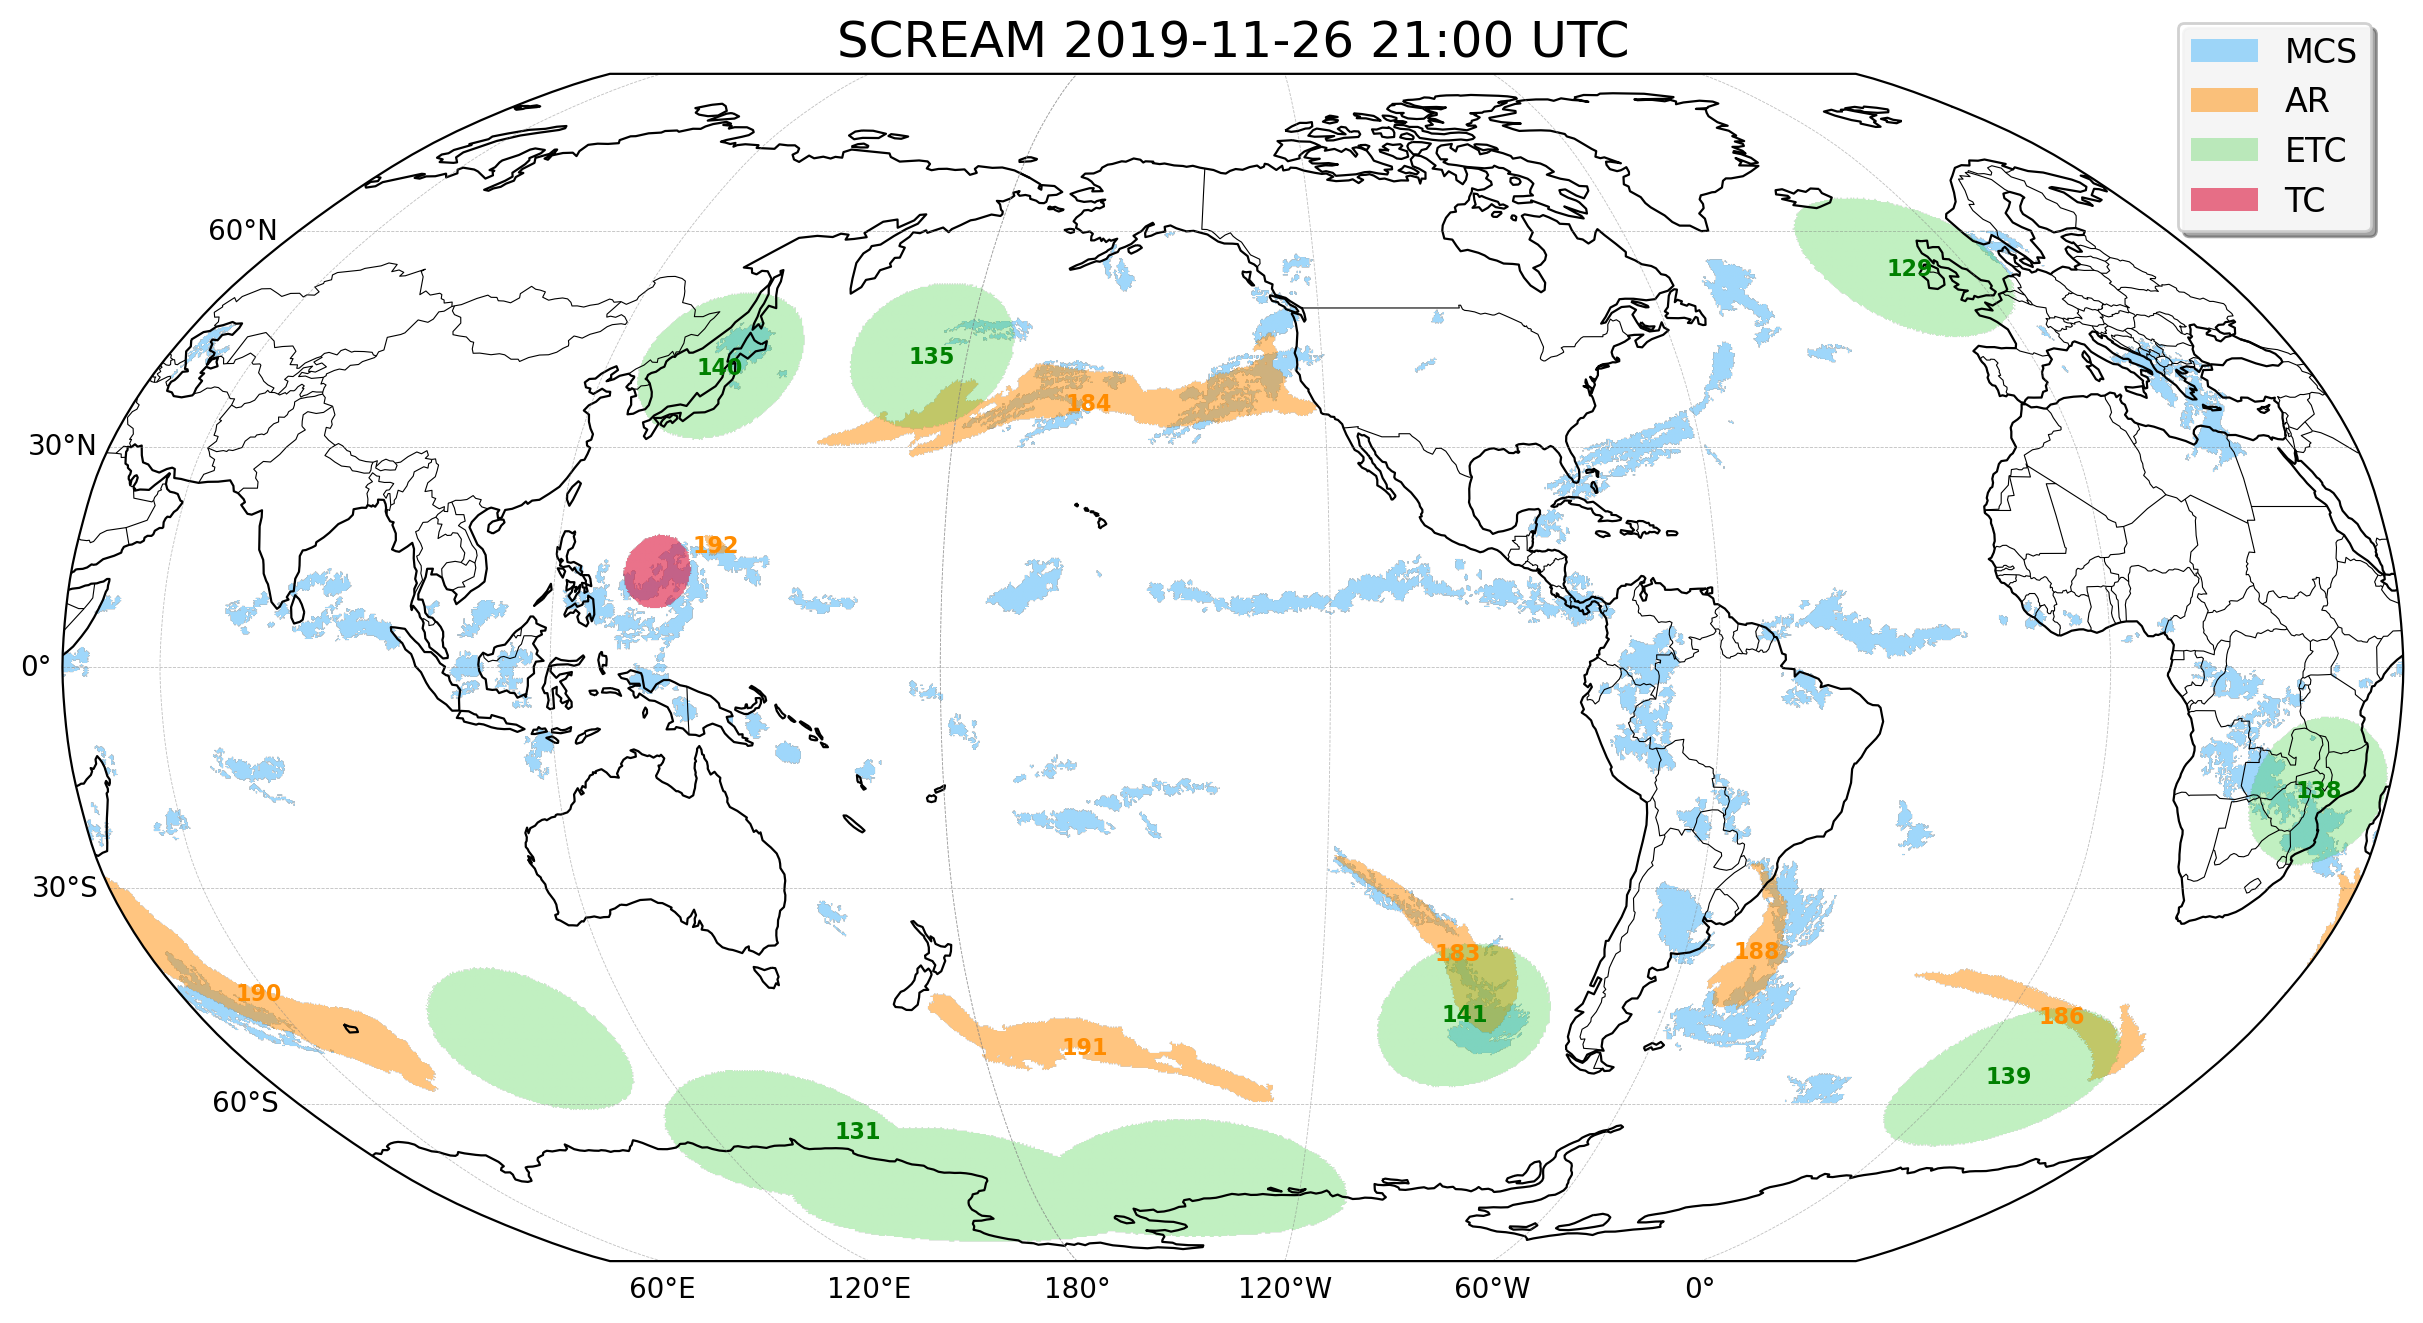

In [5]:
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    figname=figname,
    dpi=200,
    show_track_labels=True,
    track_fontsize=8
)
plt.show()

## Core Analysis Functions

These functions implement the improved overlap detection algorithms with meteorological awareness.

In [6]:
def find_overlapping_tracks_and_pairs(mask1, mask2, binary_sum_mask, 
                                     thresh1=0.1, thresh2=0.1, overlap_threshold=1,
                                     feature1_name="Feature1", feature2_name="Feature2", verbose=True):
    """
    Find overlapping tracks for both feature types AND their valid pairs in a single pass.
    
    Parameters:
    -----------
    mask1, mask2 : xarray.DataArray
        Track masks for the two feature types to analyze
    binary_sum_mask : xarray.DataArray
        Binary summation mask indicating overlap regions
    thresh1, thresh2 : float
        Minimum overlap fractions for each feature type
    overlap_threshold : int, default=1
        Minimum value in binary_sum_mask for overlap detection
    feature1_name, feature2_name : str
        Names of the feature types for reporting
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Combined results containing:
        - 'feature1_results': overlap results for feature1 (like find_overlapping_tracks)
        - 'feature2_results': overlap results for feature2 (like find_overlapping_tracks) 
        - 'valid_pairs': list of (track1_id, track2_id) tuples
        - 'feature1_tracks': numpy array of feature1 track IDs in valid pairs
        - 'feature2_tracks': numpy array of feature2 track IDs in valid pairs
        - 'pair_details': detailed information about each pair
    """
    if verbose:
        print(f"Finding {feature1_name}-{feature2_name} overlaps and pairs with thresholds: {thresh1:.1%}, {thresh2:.1%}")
    
    # Step 1: Find overlap condition (shared between both features)
    overlap_condition = (binary_sum_mask > overlap_threshold) & ~np.isnan(binary_sum_mask) & ~np.isnan(mask1) & ~np.isnan(mask2)
    
    # Step 2: Get overlapping tracks for both features in one pass
    # Feature 1 overlapping tracks
    tracks1_in_overlap, overlap1_counts = np.unique(mask1.where(overlap_condition), return_counts=True)
    valid_mask1 = ~np.isnan(tracks1_in_overlap)
    tracks1_in_overlap = tracks1_in_overlap[valid_mask1]
    overlap1_counts = overlap1_counts[valid_mask1]
    
    # Feature 2 overlapping tracks
    tracks2_in_overlap, overlap2_counts = np.unique(mask2.where(overlap_condition), return_counts=True)
    valid_mask2 = ~np.isnan(tracks2_in_overlap)
    tracks2_in_overlap = tracks2_in_overlap[valid_mask2]
    overlap2_counts = overlap2_counts[valid_mask2]
    
    # Step 3: Get total pixel counts for all tracks (shared computation)
    unique_tracks1, total1_counts = np.unique(mask1, return_counts=True)
    unique_tracks2, total2_counts = np.unique(mask2, return_counts=True)
    
    track1_counts_dict = dict(zip(unique_tracks1, total1_counts))
    track2_counts_dict = dict(zip(unique_tracks2, total2_counts))
    
    # Step 4: Calculate overlap fractions for both features
    total1_pixel_counts = np.array([track1_counts_dict.get(track, 0) for track in tracks1_in_overlap])
    total2_pixel_counts = np.array([track2_counts_dict.get(track, 0) for track in tracks2_in_overlap])
    
    overlap1_fractions = overlap1_counts / total1_pixel_counts
    overlap2_fractions = overlap2_counts / total2_pixel_counts
    
    # Step 5: Find tracks exceeding overlap thresholds
    threshold1_mask = overlap1_fractions >= thresh1
    threshold2_mask = overlap2_fractions >= thresh2
    
    tracks1_exceeding = tracks1_in_overlap[threshold1_mask]
    tracks2_exceeding = tracks2_in_overlap[threshold2_mask]
    
    # Step 6: EFFICIENT PAIR FINDING using vectorized operations
    # Create masks for tracks that exceed thresholds
    mask1_qualifying = np.isin(mask1, tracks1_exceeding)
    mask2_qualifying = np.isin(mask2, tracks2_exceeding)
    
    # Find pixels where both qualifying tracks overlap
    mutual_overlap_pixels = mask1_qualifying & mask2_qualifying & overlap_condition
    
    if mutual_overlap_pixels.sum().compute().item() > 0:
        # Get track pairs that actually overlap spatially
        track1_values = mask1.where(mutual_overlap_pixels).values
        track2_values = mask2.where(mutual_overlap_pixels).values
        
        # Remove NaN values and create coordinate pairs
        valid_overlap = ~np.isnan(track1_values) & ~np.isnan(track2_values)
        track1_valid = track1_values[valid_overlap]
        track2_valid = track2_values[valid_overlap]
        
        # Find unique pairs using numpy operations
        pair_coords = np.column_stack([track1_valid, track2_valid])
        unique_pairs = np.unique(pair_coords, axis=0)
        
        valid_pairs = [(int(pair[0]), int(pair[1])) for pair in unique_pairs]
    else:
        valid_pairs = []
    
    # Step 7: Create detailed results (similar to original functions)
    overlap1_fractions_dict = {tracks1_in_overlap[i]: overlap1_fractions[i] for i in range(len(tracks1_in_overlap))}
    overlap2_fractions_dict = {tracks2_in_overlap[i]: overlap2_fractions[i] for i in range(len(tracks2_in_overlap))}
    
    # Create pair details
    pair_details = {}
    for track1, track2 in valid_pairs:
        # Count overlap pixels for this specific pair
        track1_pixels = (mask1 == track1)
        track2_pixels = (mask2 == track2)
        pair_overlap = track1_pixels & track2_pixels & overlap_condition
        overlap_pixel_count = pair_overlap.sum().compute().item()
        
        pair_details[(track1, track2)] = {
            'overlap_pixels': overlap_pixel_count,
            'track1_fraction': overlap1_fractions_dict.get(track1, 0),
            'track2_fraction': overlap2_fractions_dict.get(track2, 0)
        }
    
    # Extract unique track lists from valid pairs
    if valid_pairs:
        paired_feature1_tracks = np.unique([pair[0] for pair in valid_pairs])
        paired_feature2_tracks = np.unique([pair[1] for pair in valid_pairs])
    else:
        paired_feature1_tracks = np.array([])
        paired_feature2_tracks = np.array([])
    
    if verbose:
        print(f"Feature1 ({feature1_name}): {len(tracks1_exceeding)} tracks exceed {thresh1:.1%} threshold")
        print(f"Feature2 ({feature2_name}): {len(tracks2_exceeding)} tracks exceed {thresh2:.1%} threshold")
        print(f"Found {len(valid_pairs)} valid pairs with spatial overlap")
        if len(valid_pairs) > 0 and len(valid_pairs) <= 10:
            print(f"  Pairs: {valid_pairs}")
    
    return {
        'feature1_results': {
            'tracks_exceeding_threshold': tracks1_exceeding,
            'overlap_fractions': overlap1_fractions_dict,
            'total_tracks_analyzed': len(unique_tracks1),
            'threshold_info': {'min_overlap_fraction': thresh1, 'overlap_threshold': overlap_threshold}
        },
        'feature2_results': {
            'tracks_exceeding_threshold': tracks2_exceeding,
            'overlap_fractions': overlap2_fractions_dict,
            'total_tracks_analyzed': len(unique_tracks2),
            'threshold_info': {'min_overlap_fraction': thresh2, 'overlap_threshold': overlap_threshold}
        },
        'valid_pairs': valid_pairs,
        'feature1_tracks': paired_feature1_tracks,
        'feature2_tracks': paired_feature2_tracks,
        'pair_details': pair_details
    }

print("✅ find_overlapping_tracks_and_pairs() function defined")

✅ find_overlapping_tracks_and_pairs() function defined


In [7]:
def find_true_3way_overlaps(mcs_mask, ar_mask, etc_mask, binary_sum_mask,
                          mcs_thresh=0.2, ar_thresh=0.1, etc_thresh=0.0, verbose=True):
    """
    Find tracks that have true 3-way overlaps with mutual spatial verification.
    
    This function ensures that all three features actually overlap spatially,
    not just that they individually exceed thresholds in 3-way regions.
    
    Parameters:
    -----------
    mcs_mask, ar_mask, etc_mask : xarray.DataArray
        Track masks for the three feature types
    binary_sum_mask : xarray.DataArray
        Binary summation mask where values == 3 indicate true 3-way overlaps
    mcs_thresh, ar_thresh, etc_thresh : float
        Minimum overlap fractions for each feature type
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Results containing validated 3-way overlaps with mutual verification
    """
    if verbose:
        print("Finding true 3-way overlaps with mutual spatial verification...")
    
    # Create 3-way overlap mask (only where all 3 features overlap)
    threeway_mask = (binary_sum_mask == 3).astype(int)
    threeway_pixels = threeway_mask.sum().compute().item()
    
    if verbose:
        print(f"Total 3-way overlap pixels: {threeway_pixels}")
    
    if threeway_pixels == 0:
        return {
            'mcs_tracks': np.array([]),
            'ar_tracks': np.array([]),
            'etc_tracks': np.array([]),
            'validated_triplets': [],
            'triplet_details': {}
        }
    
    # Find all tracks that have any presence in 3-way regions
    mcs_in_3way = np.unique(mcs_mask.values[threeway_mask > 0])
    mcs_in_3way = mcs_in_3way[mcs_in_3way > 0]
    
    ar_in_3way = np.unique(ar_mask.values[threeway_mask > 0])
    ar_in_3way = ar_in_3way[ar_in_3way > 0]
    
    etc_in_3way = np.unique(etc_mask.values[threeway_mask > 0])
    etc_in_3way = etc_in_3way[etc_in_3way > 0]
    
    validated_triplets = []
    triplet_details = {}
    valid_mcs = []
    valid_ar = []
    valid_etc = []
    
    # For each potential triplet, verify mutual overlap and thresholds
    for mcs_id in mcs_in_3way:
        for ar_id in ar_in_3way:
            for etc_id in etc_in_3way:
                # Get pixels for each track
                mcs_pixels = (mcs_mask == mcs_id)
                ar_pixels = (ar_mask == ar_id)
                etc_pixels = (etc_mask == etc_id)
                
                # Find the intersection of all three tracks in 3-way regions
                mutual_overlap = mcs_pixels & ar_pixels & etc_pixels & (threeway_mask > 0)
                overlap_count = mutual_overlap.sum().compute().item()
                
                if overlap_count > 0:
                    # Calculate overlap fractions for each track
                    mcs_total = mcs_pixels.sum().compute().item()
                    ar_total = ar_pixels.sum().compute().item()
                    etc_total = etc_pixels.sum().compute().item()
                    
                    mcs_fraction = overlap_count / mcs_total if mcs_total > 0 else 0
                    ar_fraction = overlap_count / ar_total if ar_total > 0 else 0
                    etc_fraction = overlap_count / etc_total if etc_total > 0 else 0
                    
                    # Check if all tracks meet their thresholds
                    if (mcs_fraction >= mcs_thresh and 
                        ar_fraction >= ar_thresh and 
                        etc_fraction >= etc_thresh):
                        
                        triplet = (mcs_id, ar_id, etc_id)
                        validated_triplets.append(triplet)
                        valid_mcs.append(mcs_id)
                        valid_ar.append(ar_id)
                        valid_etc.append(etc_id)
                        
                        triplet_details[triplet] = {
                            'overlap_pixels': overlap_count,
                            'mcs_fraction': mcs_fraction,
                            'ar_fraction': ar_fraction,
                            'etc_fraction': etc_fraction
                        }
    
    # Remove duplicates
    valid_mcs = np.unique(valid_mcs)
    valid_ar = np.unique(valid_ar)
    valid_etc = np.unique(valid_etc)
    
    if verbose:
        print(f"Validated 3-way overlaps:")
        print(f"  {len(validated_triplets)} triplets found")
        print(f"  MCS tracks: {len(valid_mcs)} - {valid_mcs}")
        print(f"  AR tracks: {len(valid_ar)} - {valid_ar}")
        print(f"  ETC tracks: {len(valid_etc)} - {valid_etc}")
        if len(validated_triplets) > 0 and len(validated_triplets) <= 5:
            print(f"  Triplets: {validated_triplets}")
    
    return {
        'mcs_tracks': valid_mcs,
        'ar_tracks': valid_ar,
        'etc_tracks': valid_etc,
        'validated_triplets': validated_triplets,
        'triplet_details': triplet_details
    }

print("✅ find_true_3way_overlaps() function defined")

✅ find_true_3way_overlaps() function defined


## Binary Mask Creation

Create binary masks and summation masks for overlap detection.

In [8]:
# CREATE BINARY MASKS FOR OVERLAP ANALYSIS
print("Creating binary masks for overlap analysis...")

# Create binary masks (1 where feature exists, 0 elsewhere)
mcs_binary = xr.where(_ds.mcs_mask > 0, 1, 0)
ar_binary = xr.where(_ds.ar_mask > 0, 1, 0)
etc_binary = xr.where(_ds.etc_mask > 0, 1, 0)

# Create pairwise summation masks
mcs_ar_sum = mcs_binary + ar_binary
ar_etc_sum = ar_binary + etc_binary  
mcs_etc_sum = mcs_binary + etc_binary

# Create 3-way summation mask
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

print("✅ Binary masks created successfully")

# Display overlap statistics
print(f"\nOverlap region statistics:")
print(f"  MCS-AR 2-way overlaps: {(mcs_ar_sum == 2).sum().compute().item()} pixels")
print(f"  AR-ETC 2-way overlaps: {(ar_etc_sum == 2).sum().compute().item()} pixels")
print(f"  MCS-ETC 2-way overlaps: {(mcs_etc_sum == 2).sum().compute().item()} pixels")
print(f"  3-way overlaps: {(mcs_ar_etc_sum == 3).sum().compute().item()} pixels")

Creating binary masks for overlap analysis...
✅ Binary masks created successfully

Overlap region statistics:
  MCS-AR 2-way overlaps: 3593 pixels
  AR-ETC 2-way overlaps: 3024 pixels
  MCS-ETC 2-way overlaps: 3444 pixels
  3-way overlaps: 585 pixels


## Meteorologically-Informed Overlap Analysis

Apply the improved thresholds that respect atmospheric scale hierarchy.

## Filter MCS masks that overlap with Tropical Cyclones (TC)

Before performing the meteorologically-informed overlap analysis, we need to identify and remove MCS features that significantly overlap with tropical cyclones (TC) to avoid double-counting convective activity that is primarily driven by TC dynamics.

In [9]:
def filter_mcs_tc_overlaps(mcs_mask, tc_mask, overlap_threshold=0.15, verbose=True):
    """
    Filter MCS tracks that significantly overlap with tropical cyclones using vectorized operations.
    
    This function follows the efficient approach from find_overlapping_tracks_and_pairs:
    - Creates binary masks and sums them to find overlap regions
    - Extracts MCS track IDs from overlap regions using vectorized operations
    - Calculates overlap fractions efficiently without loops
    - Returns filtered MCS mask with TC-overlapping tracks removed
    
    Parameters:
    -----------
    mcs_mask : xarray.DataArray
        Original MCS mask with track IDs (values > 0 indicate tracks)
    tc_mask : xarray.DataArray  
        TC mask with track IDs (values > 0 indicate tracks)
    overlap_threshold : float, default=0.15
        Fractional overlap threshold (0.15 = 15%). MCS tracks with overlap 
        fraction >= threshold will be identified for removal
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    xarray.DataArray : Filtered MCS mask containing only tracks that overlap with TC
        Returns the original MCS tracks that exceed the overlap threshold with TC.
        Note: This returns the overlapping tracks, not the filtered-out tracks.
        
    Raises:
    -------
    ValueError : If inputs have incompatible shapes or invalid threshold values
    TypeError : If inputs are not xarray DataArrays
    """

    # =============================================================================
    # STEP 1: CREATE BINARY MASKS AND FIND OVERLAP REGIONS
    # =============================================================================

    # Create binary masks (1 where feature exists, 0 elsewhere)
    # Handle NaN values by treating them as 0
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    # Sum binary masks to identify overlap regions
    # Values of 2 indicate pixels where both MCS and TC exist
    binary_sum_mask = mcs_binary + tc_binary

    # =============================================================================
    # STEP 2: DEFINE OVERLAP CONDITION WITH ROBUST NaN HANDLING
    # =============================================================================

    # Find overlap condition: pixels where both features exist AND no NaN values
    # Note: Using >= 2 instead of > overlap_threshold because binary_sum_mask contains integers
    overlap_condition = (
        (binary_sum_mask >= 2) &  # Both features present
        ~np.isnan(binary_sum_mask) &  # No NaN in sum
        ~np.isnan(mcs_mask) &  # No NaN in MCS mask
        ~np.isnan(tc_mask)  # No NaN in TC mask
    )

    # Check if any overlaps exist
    total_overlap_pixels = overlap_condition.sum().compute().item()
    if total_overlap_pixels == 0:
        if verbose:
            print("No MCS-TC overlaps found, returning empty mask")
        return xr.zeros_like(mcs_mask)
    
    if verbose:
        print(f"Found {total_overlap_pixels} overlap pixels")

    # =============================================================================
    # STEP 3: VECTORIZED EXTRACTION OF OVERLAPPING MCS TRACKS
    # =============================================================================

    # Extract MCS track IDs that appear in overlap regions (vectorized operation)
    # This gets ALL MCS tracks that have ANY overlap with TC
    tracks_in_overlap, overlap_counts = np.unique(
        mcs_mask.where(overlap_condition), return_counts=True
    )

    # Remove NaN values from the results
    valid_mask = ~np.isnan(tracks_in_overlap)
    tracks_in_overlap = tracks_in_overlap[valid_mask]
    overlap_counts = overlap_counts[valid_mask]
    
    # Edge case: No valid tracks found in overlap regions
    if len(tracks_in_overlap) == 0:
        if verbose:
            print("No valid MCS tracks found in overlap regions, returning empty mask")
        return xr.zeros_like(mcs_mask)
    
    if verbose:
        print(f"Found {len(tracks_in_overlap)} MCS tracks with TC overlap")

    # =============================================================================
    # STEP 4: VECTORIZED CALCULATION OF TOTAL TRACK SIZES
    # =============================================================================

    # Get total pixel counts for ALL MCS tracks (not just overlapping ones)
    # This is needed to calculate overlap fractions
    unique_tracks, total_counts = np.unique(mcs_mask, return_counts=True)
    
    # Create lookup dictionary for efficient access
    # Remove NaN key if present (np.unique includes NaN as a unique value)
    track_counts_dict = {}
    for track_id, count in zip(unique_tracks, total_counts):
        if not np.isnan(track_id):
            track_counts_dict[track_id] = count

    # =============================================================================
    # STEP 5: VECTORIZED OVERLAP FRACTION CALCULATION
    # =============================================================================
    
    # Get total pixel counts for tracks that have overlaps (vectorized lookup)
    total_pixel_counts = np.array([
        track_counts_dict.get(track, 0) for track in tracks_in_overlap
    ])

    # Edge case: Check for zero-sized tracks (should not happen but safety check)
    if np.any(total_pixel_counts == 0):
        if verbose:
            print("Warning: Found tracks with zero pixels, filtering them out")
        valid_indices = total_pixel_counts > 0
        tracks_in_overlap = tracks_in_overlap[valid_indices]
        overlap_counts = overlap_counts[valid_indices]
        total_pixel_counts = total_pixel_counts[valid_indices]
        
        if len(tracks_in_overlap) == 0:
            if verbose:
                print("No valid tracks remaining after filtering, returning empty mask")
            return xr.zeros_like(mcs_mask)
    
    # Calculate overlap fractions for all tracks at once (vectorized)
    overlap_fractions = overlap_counts / total_pixel_counts

    # =============================================================================
    # STEP 6: APPLY THRESHOLD AND IDENTIFY QUALIFYING TRACKS
    # =============================================================================
    
    # Find tracks that exceed the overlap threshold (vectorized comparison)
    threshold_mask = overlap_fractions >= overlap_threshold
    tracks_exceeding = tracks_in_overlap[threshold_mask]
    
    if verbose:
        n_exceeding = len(tracks_exceeding)
        n_total = len(tracks_in_overlap)
        print(f"Tracks exceeding {overlap_threshold:.1%} threshold: {n_exceeding}/{n_total}")
        
        if n_exceeding > 0 and n_exceeding <= 10:  # Show details for small numbers
            exceeding_fractions = overlap_fractions[threshold_mask]
            for track_id, fraction in zip(tracks_exceeding, exceeding_fractions):
                print(f"  Track {int(track_id)}: {fraction:.0%} overlap")
    
    # Edge case: No tracks exceed threshold
    if len(tracks_exceeding) == 0:
        if verbose:
            print("No tracks exceed overlap threshold, returning empty mask")
        return xr.zeros_like(mcs_mask)

    # =============================================================================
    # STEP 7: CREATE FILTERED MASK USING VECTORIZED OPERATIONS
    # =============================================================================
    
    # Start with a copy of the original MCS mask
    mcs_filtered = mcs_mask.copy()
    
    # Remove tracks that exceed the overlap threshold (vectorized operation)
    # Use np.isin to create a mask of pixels belonging to tracks that should be removed
    tracks_to_remove_mask = np.isin(mcs_mask, tracks_exceeding)
    
    # Set pixels belonging to tracks that exceed threshold to 0
    # This is a vectorized operation that works efficiently on the entire array
    mcs_filtered = xr.where(tracks_to_remove_mask, 0, mcs_filtered)
    
    # =============================================================================
    # STEP 8: COMPILE DETAILED OVERLAP STATISTICS
    # =============================================================================

    original_tracks = np.unique(mcs_mask.values[mcs_mask.values > 0])
    remaining_tracks = np.unique(mcs_filtered.values[mcs_filtered.values > 0])

    n_mcs_original = len(original_tracks)
    n_mcs_final = len(remaining_tracks)
    n_removed = n_mcs_original - n_mcs_final
    retention_rate = n_mcs_final / n_mcs_original if n_mcs_original > 0 else 0.0
    
    if verbose:
        print(f"\nTC Filtering Results:")
        print(f"  Original MCS tracks: {n_mcs_original}")
        print(f"  MCS tracks removed due to TC overlap: {n_removed}")
        print(f"  Remaining tracks: {n_mcs_final}")
        print(f"  Retention rate: {retention_rate:.1%}")
    
    # Prepare summary
    summary = {
        'initial_count': n_mcs_original,
        'removed_count': n_removed,
        'final_count': n_mcs_final,
        'retention_rate': retention_rate
    }
    
    return {
        'mcs_filtered': mcs_filtered,
        'removed_tracks': tracks_to_remove_mask,
        'summary': summary
    }

print("✅ filter_mcs_tc_overlaps() function defined")

✅ filter_mcs_tc_overlaps() function defined


In [10]:
# APPLY VECTORIZED MCS-TC FILTERING
print("🚀 APPLYING MCS-TC FILTERING")
print("="*45)

# Apply TC filtering to MCS masks
tc_filtering_results = filter_mcs_tc_overlaps(
    mcs_mask=_ds.mcs_mask,
    tc_mask=_ds.tc_mask,
    overlap_threshold=0.10,  # 10% threshold
    verbose=True
)

# Extract results
mcs_filtered = tc_filtering_results['mcs_filtered']
mcs_to_remove = tc_filtering_results['removed_tracks']
# mcs_tc_overlap_stats = tc_filtering_results['overlap_stats']
filtering_summary = tc_filtering_results['summary']

# Update the dataset with filtered MCS mask
_ds = _ds.assign(mcs_mask_original=_ds.mcs_mask, mcs_mask=mcs_filtered)

# Update feature counts for subsequent analysis
n_mcs = filtering_summary['final_count']

# Update binary masks for downstream analysis
mcs_binary = (mcs_filtered > 0).astype(int)

print(f"\nUpdated feature counts for overlap analysis:")
print(f"  MCS tracks (TC-filtered): {n_mcs}")
print(f"  AR tracks: {n_ar}")
print(f"  ETC tracks: {n_etc}")
print(f"  TC tracks: {n_tc}")

print(f"\n✅ MCS-TC filtering complete!")

🚀 APPLYING MCS-TC FILTERING
Found 615 overlap pixels
Found 2 MCS tracks with TC overlap
Tracks exceeding 10.0% threshold: 1/2
  Track 16392: 69% overlap

TC Filtering Results:
  Original MCS tracks: 115
  MCS tracks removed due to TC overlap: 1
  Remaining tracks: 114
  Retention rate: 99.1%

Updated feature counts for overlap analysis:
  MCS tracks (TC-filtered): 114
  AR tracks: 7
  ETC tracks: 7
  TC tracks: 1

✅ MCS-TC filtering complete!


<Figure size 921.6x691.2 with 0 Axes>

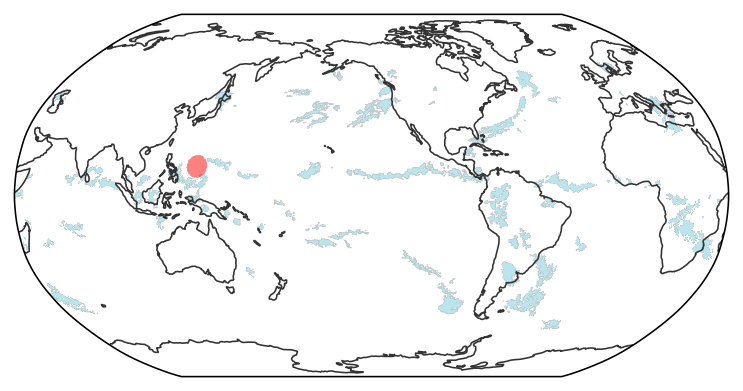

In [11]:
egh.healpix_show(mcs_filtered.where(mcs_filtered>0), vmin=mcs_filtered.min(), vmax=mcs_filtered.max(), cmap='tab20', alpha=0.7)
# egh.healpix_show(tracks_remove_mask.where(tracks_remove_mask>0), vmin=_mcs_filtered.min(), vmax=_mcs_filtered.max(), cmap='tab20')
tc_mask = _ds.tc_mask
tc_binary = xr.where(tc_mask > 0, 1, 0)
egh.healpix_show(tc_binary.where(tc_binary>0), vmin=0.5, vmax=1.5, cmap=mpl.colors.ListedColormap(['red']), alpha=0.5)

In [12]:
# UPDATE BINARY MASKS AND OVERLAP SUMS WITH FILTERED MCS DATA
print("\nUpdating binary masks and overlap sums with TC-filtered MCS data...")

# Recalculate pairwise summation masks with filtered MCS
mcs_ar_sum = mcs_binary + ar_binary
ar_etc_sum = ar_binary + etc_binary  
mcs_etc_sum = mcs_binary + etc_binary

# Recalculate 3-way summation mask with filtered MCS
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

print("✅ Binary masks and overlap sums updated with TC-filtered MCS data")

# Display updated overlap statistics
print(f"\nUpdated overlap region statistics (with TC-filtered MCS):")
print(f"  MCS-AR overlaps: {(mcs_ar_sum == 2).sum().compute().item()} pixels")
print(f"  AR-ETC overlaps: {(ar_etc_sum == 2).sum().compute().item()} pixels")
print(f"  MCS-ETC overlaps: {(mcs_etc_sum == 2).sum().compute().item()} pixels")
print(f"  3-way overlaps: {(mcs_ar_etc_sum == 3).sum().compute().item()} pixels")


Updating binary masks and overlap sums with TC-filtered MCS data...
✅ Binary masks and overlap sums updated with TC-filtered MCS data

Updated overlap region statistics (with TC-filtered MCS):
  MCS-AR overlaps: 3593 pixels
  AR-ETC overlaps: 3024 pixels
  MCS-ETC overlaps: 3444 pixels
  3-way overlaps: 585 pixels


In [13]:
# METEOROLOGICALLY-INFORMED OVERLAP ANALYSIS
print("Performing meteorologically-informed overlap analysis...")
print("="*60)

# Define thresholds based on atmospheric scale hierarchy
mcs_thresh = 0.20  # 20% - smallest features, need substantial overlap
ar_thresh = 0.10   # 10% - medium features
etc_thresh_2way = 0.05  # 5% - largest features for 2-way overlaps
etc_thresh_3way = 0.00  # 0% - environmental context for 3-way overlaps

print(f"Overlap thresholds:")
print(f"  MCS: {mcs_thresh:.0%} (all scenarios)")
print(f"  AR: {ar_thresh:.0%} (all scenarios)")
print(f"  ETC: {etc_thresh_2way:.0%} (2-way), {etc_thresh_3way:.0%} (3-way)")

# 1. 3-WAY OVERLAPS WITH MUTUAL SPATIAL VERIFICATION
print(f"\n1. 3-WAY OVERLAPS:")
print("-" * 20)

# Apply 3-way overlap function
validated_3way = find_true_3way_overlaps(
    _ds.mcs_mask, _ds.ar_mask, _ds.etc_mask, mcs_ar_etc_sum,
    mcs_thresh, ar_thresh, etc_thresh_3way, verbose=True
)

# Extract validated tracks
mcs_tracks_with_ar_etc_overlap = validated_3way['mcs_tracks']
ar_tracks_with_mcs_etc_overlap = validated_3way['ar_tracks']
etc_tracks_with_mcs_ar_overlap = validated_3way['etc_tracks']
validated_triplets = validated_3way['validated_triplets']

print(f"\nValidated 3-way overlap results:")
print(f"  MCS tracks: {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"  AR tracks: {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"  ETC tracks: {len(etc_tracks_with_mcs_ar_overlap)}")
print(f"  Total triplets: {len(validated_triplets)}")

# 2. 2-WAY PAIRS WITH EXCLUSION OF 3-WAY PARTICIPANTS
print(f"\n2. 2-WAY PAIRS (excluding 3-way participants):")
print("-" * 45)

# Find all potential 2-way overlaps
mcs_ar_pairs_all = find_overlapping_tracks_and_pairs(_ds.mcs_mask, _ds.ar_mask, mcs_ar_sum,
                                                    mcs_thresh, 0.0, overlap_threshold=1,
                                                    feature1_name="MCS", feature2_name="AR")

ar_etc_pairs_all = find_overlapping_tracks_and_pairs(_ds.ar_mask, _ds.etc_mask, ar_etc_sum,
                                                    ar_thresh, 0.01, overlap_threshold=1,
                                                    feature1_name="AR", feature2_name="ETC")

mcs_etc_pairs_all = find_overlapping_tracks_and_pairs(_ds.mcs_mask, _ds.etc_mask, mcs_etc_sum,
                                                     mcs_thresh, 0.0, overlap_threshold=1,
                                                     feature1_name="MCS", feature2_name="ETC")

# Filter out tracks that ACTUALLY EXCEED 3-way thresholds (not just participate)
mcs_ar_pairs_2way_only = [pair for pair in mcs_ar_pairs_all['valid_pairs']
                         if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                         and pair[1] not in ar_tracks_with_mcs_etc_overlap]

ar_etc_pairs_2way_only = [pair for pair in ar_etc_pairs_all['valid_pairs']
                         if pair[0] not in ar_tracks_with_mcs_etc_overlap 
                         and pair[1] not in etc_tracks_with_mcs_ar_overlap]

mcs_etc_pairs_2way_only = [pair for pair in mcs_etc_pairs_all['valid_pairs']
                          if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                          and pair[1] not in etc_tracks_with_mcs_ar_overlap]

print(f"\n2-way pair results (excluding 3-way participants):")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")

# Debug output to check specific tracks
print(f"\nDebug - Validated 3-way tracks:")
print(f"  MCS (>= {mcs_thresh*100}%): {mcs_tracks_with_ar_etc_overlap}")
print(f"  AR (>= {ar_thresh*100}%): {ar_tracks_with_mcs_etc_overlap}")
print(f"  ETC (> {etc_thresh_3way*100}%): {etc_tracks_with_mcs_ar_overlap}")
if len(validated_triplets) > 0:
    print(f"  Validated triplets (MCS, AR, ETC): {validated_triplets}")

print(f"\n✅ Meteorologically-informed overlap analysis complete!")

Performing meteorologically-informed overlap analysis...
Overlap thresholds:
  MCS: 20% (all scenarios)
  AR: 10% (all scenarios)
  ETC: 5% (2-way), 0% (3-way)

1. 3-WAY OVERLAPS:
--------------------
Finding true 3-way overlaps with mutual spatial verification...
Total 3-way overlap pixels: 585
Validated 3-way overlaps:
  1 triplets found
  MCS tracks: 1 - [15960.]
  AR tracks: 1 - [183]
  ETC tracks: 1 - [141]
  Triplets: [(np.float64(15960.0), np.int32(183), np.int32(141))]

Validated 3-way overlap results:
  MCS tracks: 1
  AR tracks: 1
  ETC tracks: 1
  Total triplets: 1

2. 2-WAY PAIRS (excluding 3-way participants):
---------------------------------------------
Finding MCS-AR overlaps and pairs with thresholds: 20.0%, 0.0%
Feature1 (MCS): 8 tracks exceed 20.0% threshold
Feature2 (AR): 5 tracks exceed 0.0% threshold
Found 8 valid pairs with spatial overlap
  Pairs: [(15960, 183), (16277, 190), (16323, 188), (16335, 184), (16361, 184), (16375, 184), (16383, 190), (16430, 183)]
Fin

In [14]:
def promote_dual_etc_overlaps_to_3way(mcs_ar_pairs_2way, ar_etc_pairs_2way, mcs_etc_pairs_2way, 
                                     existing_3way_tracks=None, verbose=True):
    """
    Identifies ETC tracks with dual 2-way overlaps and promotes them to 3-way,
    including ALL tracks that have 2-way overlaps with any of the promoted tracks.
    
    This ensures comprehensive grouping - if AR 184 gets promoted to 3-way with MCS 16470 and ETC 142,
    then ALL MCS tracks that overlap with AR 184 (e.g., MCS 16443) are also included in 3-way.
    
    Parameters:
    -----------
    mcs_ar_pairs_2way : list
        List of (mcs_track, ar_track) tuples for MCS-AR 2-way pairs
    ar_etc_pairs_2way : list
        List of (ar_track, etc_track) tuples for AR-ETC 2-way pairs  
    mcs_etc_pairs_2way : list
        List of (mcs_track, etc_track) tuples for MCS-ETC 2-way pairs
    existing_3way_tracks : dict, optional
        Existing 3-way tracks to merge with new ones
    verbose : bool, default=True
        Whether to print detailed information
        
    Returns:
    --------
    dict : Results with comprehensive track grouping
    """
    
    if verbose:
        print("🔍 IDENTIFYING ETC TRACKS WITH DUAL 2-WAY OVERLAPS")
        print("="*55)
    
    # Step 1: Find ETC tracks with dual overlaps (same as before)
    etc_tracks_in_ar_etc = set([pair[1] for pair in ar_etc_pairs_2way])
    etc_tracks_in_mcs_etc = set([pair[1] for pair in mcs_etc_pairs_2way])
    dual_etc_tracks = etc_tracks_in_ar_etc.intersection(etc_tracks_in_mcs_etc)
    
    if verbose:
        print(f"ETC tracks in AR-ETC pairs: {sorted(etc_tracks_in_ar_etc)}")
        print(f"ETC tracks in MCS-ETC pairs: {sorted(etc_tracks_in_mcs_etc)}")
        print(f"ETC tracks with dual overlaps: {sorted(dual_etc_tracks)}")
    
    if not dual_etc_tracks:
        if verbose:
            print("No ETC tracks found with dual 2-way overlaps.")
        
        return {
            'promoted_triplets': [],
            'updated_3way_tracks': existing_3way_tracks or {'mcs_tracks': np.array([]), 'ar_tracks': np.array([]), 'etc_tracks': np.array([])},
            'updated_2way_pairs': {
                'mcs_ar_pairs': mcs_ar_pairs_2way,
                'ar_etc_pairs': ar_etc_pairs_2way,
                'mcs_etc_pairs': mcs_etc_pairs_2way
            },
            'promotion_details': {}
        }
    
    # Step 2: Create initial triplets from dual ETC overlaps
    promoted_triplets = []
    core_promoted_tracks = {'mcs': set(), 'ar': set(), 'etc': set()}
    
    for etc_track in dual_etc_tracks:
        if verbose:
            print(f"\n🎯 Processing ETC track {etc_track}:")
        
        mcs_partners = [pair[0] for pair in mcs_etc_pairs_2way if pair[1] == etc_track]
        ar_partners = [pair[0] for pair in ar_etc_pairs_2way if pair[1] == etc_track]
        
        if verbose:
            print(f"  MCS partners: {mcs_partners}")
            print(f"  AR partners: {ar_partners}")
        
        for mcs_track in mcs_partners:
            for ar_track in ar_partners:
                triplet = (mcs_track, ar_track, etc_track)
                promoted_triplets.append(triplet)
                core_promoted_tracks['mcs'].add(mcs_track)
                core_promoted_tracks['ar'].add(ar_track)
                core_promoted_tracks['etc'].add(etc_track)
                
                if verbose:
                    print(f"  ✅ Core triplet: MCS {mcs_track} - AR {ar_track} - ETC {etc_track}")
    
    # Step 3: COMPREHENSIVE EXPANSION - Find ALL tracks with 2-way overlaps to promoted tracks
    comprehensive_3way_tracks = {'mcs': set(), 'ar': set(), 'etc': set()}
    
    # Start with core promoted tracks
    comprehensive_3way_tracks['mcs'].update(core_promoted_tracks['mcs'])
    comprehensive_3way_tracks['ar'].update(core_promoted_tracks['ar'])
    comprehensive_3way_tracks['etc'].update(core_promoted_tracks['etc'])
    
    if verbose:
        print(f"\n🌟 COMPREHENSIVE EXPANSION:")
        print(f"Core promoted tracks: MCS={sorted(core_promoted_tracks['mcs'])}, AR={sorted(core_promoted_tracks['ar'])}, ETC={sorted(core_promoted_tracks['etc'])}")
    
    # Add ALL MCS tracks that overlap with promoted AR tracks
    for mcs_track, ar_track in mcs_ar_pairs_2way:
        if ar_track in core_promoted_tracks['ar']:
            comprehensive_3way_tracks['mcs'].add(mcs_track)
            if verbose and mcs_track not in core_promoted_tracks['mcs']:
                print(f"  + Added MCS {mcs_track} (overlaps with promoted AR {ar_track})")
    
    # Add ALL AR tracks that overlap with promoted MCS tracks
    for mcs_track, ar_track in mcs_ar_pairs_2way:
        if mcs_track in core_promoted_tracks['mcs']:
            comprehensive_3way_tracks['ar'].add(ar_track)
            if verbose and ar_track not in core_promoted_tracks['ar']:
                print(f"  + Added AR {ar_track} (overlaps with promoted MCS {mcs_track})")
    
    # Add ALL AR tracks that overlap with promoted ETC tracks
    for ar_track, etc_track in ar_etc_pairs_2way:
        if etc_track in core_promoted_tracks['etc']:
            comprehensive_3way_tracks['ar'].add(ar_track)
            if verbose and ar_track not in core_promoted_tracks['ar']:
                print(f"  + Added AR {ar_track} (overlaps with promoted ETC {etc_track})")
    
    # Add ALL ETC tracks that overlap with promoted AR tracks
    for ar_track, etc_track in ar_etc_pairs_2way:
        if ar_track in core_promoted_tracks['ar']:
            comprehensive_3way_tracks['etc'].add(etc_track)
            if verbose and etc_track not in core_promoted_tracks['etc']:
                print(f"  + Added ETC {etc_track} (overlaps with promoted AR {ar_track})")
    
    # Add ALL MCS tracks that overlap with promoted ETC tracks
    for mcs_track, etc_track in mcs_etc_pairs_2way:
        if etc_track in core_promoted_tracks['etc']:
            comprehensive_3way_tracks['mcs'].add(mcs_track)
            if verbose and mcs_track not in core_promoted_tracks['mcs']:
                print(f"  + Added MCS {mcs_track} (overlaps with promoted ETC {etc_track})")
    
    # Add ALL ETC tracks that overlap with promoted MCS tracks
    for mcs_track, etc_track in mcs_etc_pairs_2way:
        if mcs_track in core_promoted_tracks['mcs']:
            comprehensive_3way_tracks['etc'].add(etc_track)
            if verbose and etc_track not in core_promoted_tracks['etc']:
                print(f"  + Added ETC {etc_track} (overlaps with promoted MCS {mcs_track})")
    
    # Step 4: Remove ALL comprehensive tracks from 2-way pairs
    updated_mcs_ar_pairs = [
        pair for pair in mcs_ar_pairs_2way 
        if pair[0] not in comprehensive_3way_tracks['mcs'] and pair[1] not in comprehensive_3way_tracks['ar']
    ]
    
    updated_ar_etc_pairs = [
        pair for pair in ar_etc_pairs_2way 
        if pair[0] not in comprehensive_3way_tracks['ar'] and pair[1] not in comprehensive_3way_tracks['etc']
    ]
    
    updated_mcs_etc_pairs = [
        pair for pair in mcs_etc_pairs_2way 
        if pair[0] not in comprehensive_3way_tracks['mcs'] and pair[1] not in comprehensive_3way_tracks['etc']
    ]
    
    # Convert to arrays and merge with existing 3-way tracks
    comprehensive_mcs = np.array(sorted(comprehensive_3way_tracks['mcs']))
    comprehensive_ar = np.array(sorted(comprehensive_3way_tracks['ar']))
    comprehensive_etc = np.array(sorted(comprehensive_3way_tracks['etc']))
    
    if existing_3way_tracks:
        final_mcs_3way = np.unique(np.concatenate([existing_3way_tracks['mcs_tracks'], comprehensive_mcs]))
        final_ar_3way = np.unique(np.concatenate([existing_3way_tracks['ar_tracks'], comprehensive_ar]))
        final_etc_3way = np.unique(np.concatenate([existing_3way_tracks['etc_tracks'], comprehensive_etc]))
    else:
        final_mcs_3way = comprehensive_mcs
        final_ar_3way = comprehensive_ar
        final_etc_3way = comprehensive_etc
    
    if verbose:
        print(f"\n📊 COMPREHENSIVE PROMOTION SUMMARY:")
        print(f"  Core triplets promoted: {len(promoted_triplets)}")
        print(f"  Comprehensive 3-way tracks:")
        print(f"    MCS: {len(final_mcs_3way)} tracks {sorted(final_mcs_3way)}")
        print(f"    AR: {len(final_ar_3way)} tracks {sorted(final_ar_3way)}")
        print(f"    ETC: {len(final_etc_3way)} tracks {sorted(final_etc_3way)}")
        print(f"  Updated 2-way pairs:")
        print(f"    MCS-AR: {len(updated_mcs_ar_pairs)} (was {len(mcs_ar_pairs_2way)})")
        print(f"    AR-ETC: {len(updated_ar_etc_pairs)} (was {len(ar_etc_pairs_2way)})")
        print(f"    MCS-ETC: {len(updated_mcs_etc_pairs)} (was {len(mcs_etc_pairs_2way)})")
    
    return {
        'promoted_triplets': promoted_triplets,
        'updated_3way_tracks': {
            'mcs_tracks': final_mcs_3way,
            'ar_tracks': final_ar_3way,
            'etc_tracks': final_etc_3way
        },
        'updated_2way_pairs': {
            'mcs_ar_pairs': updated_mcs_ar_pairs,
            'ar_etc_pairs': updated_ar_etc_pairs,
            'mcs_etc_pairs': updated_mcs_etc_pairs
        },
        'promotion_details': {
            'core_promoted_tracks': core_promoted_tracks,
            'comprehensive_tracks': comprehensive_3way_tracks
        }
    }

print("✅ promote_dual_etc_overlaps_to_3way() function defined")

✅ promote_dual_etc_overlaps_to_3way() function defined


In [15]:
# APPLY DUAL ETC OVERLAP PROMOTION WITH COMPREHENSIVE GROUPING
print("🚀 APPLYING DUAL ETC OVERLAP PROMOTION")
print("="*50)

# Apply promotion that includes ALL tracks overlapping with promoted tracks
comprehensive_results = promote_dual_etc_overlaps_to_3way(
    mcs_ar_pairs_2way_only, ar_etc_pairs_2way_only, mcs_etc_pairs_2way_only,
    existing_3way_tracks={
        'mcs_tracks': mcs_tracks_with_ar_etc_overlap,
        'ar_tracks': ar_tracks_with_mcs_etc_overlap,
        'etc_tracks': etc_tracks_with_mcs_ar_overlap
    },
    verbose=True
)

# Update with comprehensive results
mcs_ar_pairs_2way_only = comprehensive_results['updated_2way_pairs']['mcs_ar_pairs']
ar_etc_pairs_2way_only = comprehensive_results['updated_2way_pairs']['ar_etc_pairs']
mcs_etc_pairs_2way_only = comprehensive_results['updated_2way_pairs']['mcs_etc_pairs']

# Update 3-way tracks with comprehensive grouping
mcs_tracks_with_ar_etc_overlap = comprehensive_results['updated_3way_tracks']['mcs_tracks']
ar_tracks_with_mcs_etc_overlap = comprehensive_results['updated_3way_tracks']['ar_tracks']
etc_tracks_with_mcs_ar_overlap = comprehensive_results['updated_3way_tracks']['etc_tracks']

# Update validated triplets
comprehensive_triplets = comprehensive_results['promoted_triplets']
all_validated_triplets = validated_triplets + comprehensive_triplets

print(f"\n✅ COMPREHENSIVE PROMOTION COMPLETE!")
print(f"Final counts after comprehensive grouping:")
print(f"  2-way pairs: MCS-AR={len(mcs_ar_pairs_2way_only)}, AR-ETC={len(ar_etc_pairs_2way_only)}, MCS-ETC={len(mcs_etc_pairs_2way_only)}")
print(f"  3-way tracks: MCS={len(mcs_tracks_with_ar_etc_overlap)}, AR={len(ar_tracks_with_mcs_etc_overlap)}, ETC={len(etc_tracks_with_mcs_ar_overlap)}")
print(f"  Total triplets: {len(all_validated_triplets)} (original: {len(validated_triplets)}, comprehensive: {len(comprehensive_triplets)})")

🚀 APPLYING DUAL ETC OVERLAP PROMOTION
🔍 IDENTIFYING ETC TRACKS WITH DUAL 2-WAY OVERLAPS
ETC tracks in AR-ETC pairs: [135, 139]
ETC tracks in MCS-ETC pairs: [135, 138, 140]
ETC tracks with dual overlaps: [135]

🎯 Processing ETC track 135:
  MCS partners: [16395]
  AR partners: [184]
  ✅ Core triplet: MCS 16395 - AR 184 - ETC 135

🌟 COMPREHENSIVE EXPANSION:
Core promoted tracks: MCS=[16395], AR=[184], ETC=[135]
  + Added MCS 16335 (overlaps with promoted AR 184)
  + Added MCS 16361 (overlaps with promoted AR 184)
  + Added MCS 16375 (overlaps with promoted AR 184)

📊 COMPREHENSIVE PROMOTION SUMMARY:
  Core triplets promoted: 1
  Comprehensive 3-way tracks:
    MCS: 5 tracks [np.float64(15960.0), np.float64(16335.0), np.float64(16361.0), np.float64(16375.0), np.float64(16395.0)]
    AR: 2 tracks [np.int64(183), np.int64(184)]
    ETC: 2 tracks [np.int64(135), np.int64(141)]
  Updated 2-way pairs:
    MCS-AR: 3 (was 6)
    AR-ETC: 1 (was 2)
    MCS-ETC: 4 (was 5)

✅ COMPREHENSIVE PROMOTION

In [16]:
# EXTRACT TRACK LISTS FOR VISUALIZATION AND CHECK RESULTS
print("Extracting track lists for visualization...")

# Extract track lists from 2-way-only pairs for visualization
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_2way_only = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_2way_only = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_2way_only = np.array([])
    ar_tracks_paired_2way_only = np.array([])

if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar_2way_only = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_ar_2way_only = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs_2way_only = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_mcs_2way_only = np.array([])

print(f"Track lists extracted for visualization:")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)} pairs")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)} pairs")  
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)} pairs")
print(f"  3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC tracks")

print(f"\n✅ Track extraction complete!")

Extracting track lists for visualization...
Track lists extracted for visualization:
  MCS-AR pairs: 3 pairs
  AR-ETC pairs: 1 pairs
  MCS-ETC pairs: 4 pairs
  3-way overlaps: 5 MCS, 2 AR, 2 ETC tracks

✅ Track extraction complete!


## Create Visualization Masks

Generate the masks needed for the comprehensive 4-panel visualization.

In [17]:
# CREATE VISUALIZATION MASKS
print("Creating masks for comprehensive visualization...")

# Extract track lists from 2-way pairs for visualization
if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_ar = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_mcs = np.array([])

if mcs_ar_pairs_2way_only:
    mcs_tracks_paired = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired = np.array([])
    ar_tracks_paired = np.array([])

# Create 2-way pair masks
mcs_ar_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired), 
    _ds.mcs_mask, 
    0
)
ar_mcs_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired), 
    _ds.ar_mask, 
    0
)

ar_etc_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired_with_etc), 
    _ds.ar_mask, 
    0
)
etc_ar_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_ar), 
    _ds.etc_mask, 
    0
)

mcs_etc_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired_with_etc), 
    _ds.mcs_mask, 
    0
)
etc_mcs_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_mcs), 
    _ds.etc_mask, 
    0
)

# Create 3-way overlap masks
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)
ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)
etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)

print("✅ All visualization masks created successfully!")

print(f"\nMask verification:")
print(f"  2-way masks created for {len(mcs_ar_pairs_2way_only) + len(ar_etc_pairs_2way_only) + len(mcs_etc_pairs_2way_only)} total pairs")
print(f"  3-way masks: {(etc_mcs_ar_overlap_mask > 0).sum().item()} ETC pixels")

Creating masks for comprehensive visualization...
✅ All visualization masks created successfully!

Mask verification:
  2-way masks created for 8 total pairs
  3-way masks: 11949 ETC pixels


## Comprehensive 5-Panel Visualization

Final visualization showing all original features and co-occuring features.

In [18]:
def create_comprehensive_5panel_visualization(ds, 
                                             mcs_ar_pairs_2way, ar_etc_pairs_2way, mcs_etc_pairs_2way,
                                             mcs_tracks_3way, ar_tracks_3way, etc_tracks_3way,
                                             figdir, source_name, datetime_string, 
                                             title_suffix="Comprehensive Analysis"):
    """
    Create a comprehensive 5-panel visualization:
    - Top center: All original features with track IDs
    - Bottom rows: 4 panels showing different overlap types
    """
    
    print("🎨 Creating comprehensive 5-panel visualization...")
    
    # Helper function for circular longitude averaging
    def circular_lon_mean(lon_values):
        """Calculate circular mean for longitude values to handle dateline crossing."""
        lon_rad = np.deg2rad(lon_values)
        mean_complex = np.mean(np.exp(1j * lon_rad))
        mean_lon = np.rad2deg(np.angle(mean_complex))
        if mean_lon < 0:
            mean_lon += 360
        return mean_lon
    
    track_fontsize = 10
    mcs_fontsize = 7
    title_fontsize = 12

    # Create GridSpec layout: 3 rows, 2 columns for equal-sized panels
    # Top row spans both columns for overview panel  
    # Middle and bottom rows have 2 panels each (2x2 grid for 4 overlap panels)
    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], width_ratios=[1, 1], 
                          hspace=0.12, wspace=0.05, top=0.9, bottom=0.05, left=0.05, right=0.95)
    
    # Figure suptitle
    fig.suptitle(title_suffix, fontsize=title_fontsize*1.3, fontweight='bold', y=0.95)
    
    # Create projection for all axes
    projection = ccrs.Robinson(central_longitude=-135)
    
    # Top panel: All original features (spans both columns)
    ax_overview = fig.add_subplot(gs[0, :], projection=projection)
    
    # Bottom panels: 2x2 grid for 4 overlap types (equal size)
    ax_mcs_ar = fig.add_subplot(gs[1, 0], projection=projection)
    ax_ar_etc = fig.add_subplot(gs[1, 1], projection=projection)
    ax_mcs_etc = fig.add_subplot(gs[2, 0], projection=projection)
    ax_3way = fig.add_subplot(gs[2, 1], projection=projection)
    
    # Configure all axes
    all_axes = [ax_overview, ax_mcs_ar, ax_ar_etc, ax_mcs_etc, ax_3way]
    for ax in all_axes:
        ax.set_global()
        ax.add_feature(cf.COASTLINE, linewidth=0.5)
    
    # ==== TOP PANEL: ALL ORIGINAL FEATURES ====
    print("  📍 Creating overview panel with all features...")
    
    # Create binary masks for visualization
    mcs_binary = (ds.mcs_mask > 0).astype(float)
    ar_binary = (ds.ar_mask > 0).astype(float)
    etc_binary = (ds.etc_mask > 0).astype(float)
    tc_binary = (ds.tc_mask > 0).astype(float)
    
    # Define colors and alphas
    overview_colors = {'mcs': 'lightblue', 'ar': 'orange', 'etc': 'limegreen', 'tc': 'red'}
    overview_alphas = {'mcs': 0.6, 'ar': 0.4, 'etc': 0.3, 'tc': 0.5}
    
    # Plot features in order (MCS first, then overlays)
    if np.any(mcs_binary > 0):
        egh.healpix_show(mcs_binary.where(mcs_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]),
                        alpha=overview_alphas['mcs'], vmin=0.5, vmax=1.5)
    
    if np.any(ar_binary > 0):
        egh.healpix_show(ar_binary.where(ar_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]),
                        alpha=overview_alphas['ar'], vmin=0.5, vmax=1.5)
    
    if np.any(etc_binary > 0):
        egh.healpix_show(etc_binary.where(etc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]),
                        alpha=overview_alphas['etc'], vmin=0.5, vmax=1.5)
    
    if np.any(tc_binary > 0):
        egh.healpix_show(tc_binary.where(tc_binary > 0), ax=ax_overview,
                        cmap=mpl.colors.ListedColormap([overview_colors['tc']]),
                        alpha=overview_alphas['tc'], vmin=0.5, vmax=1.5)
    
    # Add track labels for AR and ETC (following cell 6 style)
    # track_fontsize = 10
    
    # AR track labels (orange)
    ar_tracks = np.unique(ds.ar_mask.values[ds.ar_mask.values > 0])
    for track_id in ar_tracks:
        track_pixels = (ds.ar_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='darkorange', ha='center', va='center')
    
    # ETC track labels (green)
    etc_tracks = np.unique(ds.etc_mask.values[ds.etc_mask.values > 0])
    for track_id in etc_tracks:
        track_pixels = (ds.etc_mask == track_id)
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_overview.text(avg_lon, avg_lat, str(int(track_id)),
                               transform=ccrs.PlateCarree(), fontsize=track_fontsize,
                               fontweight='bold', color='green', ha='center', va='center')
    
    # ax_overview.set_title(f"All Original Features Overview\n{title_suffix}",
    ax_overview.set_title(f"All Original Features Overview",
                         fontsize=title_fontsize, fontweight='bold', color='black')
    
    # ==== BOTTOM PANELS: OVERLAP ANALYSIS ====
    print("  📊 Creating overlap analysis panels...")
    
    # Extract track lists for 2-way pairs
    if mcs_ar_pairs_2way:
        mcs_tracks_paired = np.unique([pair[0] for pair in mcs_ar_pairs_2way])
        ar_tracks_paired = np.unique([pair[1] for pair in mcs_ar_pairs_2way])
    else:
        mcs_tracks_paired = np.array([])
        ar_tracks_paired = np.array([])
    
    if ar_etc_pairs_2way:
        ar_tracks_paired_with_etc = np.unique([pair[0] for pair in ar_etc_pairs_2way])
        etc_tracks_paired_with_ar = np.unique([pair[1] for pair in ar_etc_pairs_2way])
    else:
        ar_tracks_paired_with_etc = np.array([])
        etc_tracks_paired_with_ar = np.array([])
    
    if mcs_etc_pairs_2way:
        mcs_tracks_paired_with_etc = np.unique([pair[0] for pair in mcs_etc_pairs_2way])
        etc_tracks_paired_with_mcs = np.unique([pair[1] for pair in mcs_etc_pairs_2way])
    else:
        mcs_tracks_paired_with_etc = np.array([])
        etc_tracks_paired_with_mcs = np.array([])
    
    # Create overlap masks
    mcs_ar_mask = xr.where(ds.mcs_mask.isin(mcs_tracks_paired), ds.mcs_mask, 0)
    ar_mcs_mask = xr.where(ds.ar_mask.isin(ar_tracks_paired), ds.ar_mask, 0)

    ar_etc_mask = xr.where(ds.ar_mask.isin(ar_tracks_paired_with_etc), ds.ar_mask, 0)
    etc_ar_mask = xr.where(ds.etc_mask.isin(etc_tracks_paired_with_ar), ds.etc_mask, 0)

    mcs_etc_mask = xr.where(ds.mcs_mask.isin(mcs_tracks_paired_with_etc), ds.mcs_mask, 0)
    etc_mcs_mask = xr.where(ds.etc_mask.isin(etc_tracks_paired_with_mcs), ds.etc_mask, 0)

    mcs_3way_mask = xr.where(ds.mcs_mask.isin(mcs_tracks_3way), ds.mcs_mask, 0)
    ar_3way_mask = xr.where(ds.ar_mask.isin(ar_tracks_3way), ds.ar_mask, 0)
    etc_3way_mask = xr.where(ds.etc_mask.isin(etc_tracks_3way), ds.etc_mask, 0)
    
    # Panel 1: MCS-AR 2-way pairs
    if len(mcs_tracks_paired) > 0:
        egh.healpix_show(mcs_ar_mask.where(mcs_ar_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_tracks_paired) > 0:
        egh.healpix_show(ar_mcs_mask.where(ar_mcs_mask > 0), ax=ax_mcs_ar,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    
    # Add track labels
    for track_id in mcs_tracks_paired:
        track_pixels = ds.mcs_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_tracks_paired:
        track_pixels = ds.ar_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_ar.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    ax_mcs_ar.set_title(f"MCS-AR 2-Way\nMCS: {len(mcs_tracks_paired)}, AR: {len(ar_tracks_paired)}",
                       fontsize=title_fontsize, fontweight='bold', color='blue')
    
    # Panel 2: AR-ETC 2-way pairs
    if len(ar_tracks_paired_with_etc) > 0:
        egh.healpix_show(ar_etc_mask.where(ar_etc_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_tracks_paired_with_ar) > 0:
        egh.healpix_show(etc_ar_mask.where(etc_ar_mask > 0), ax=ax_ar_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels
    for track_id in ar_tracks_paired_with_etc:
        track_pixels = ds.ar_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_tracks_paired_with_ar:
        track_pixels = ds.etc_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_ar_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                             fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_ar_etc.set_title(f"AR-ETC 2-Way\nAR: {len(ar_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_ar)}",
                       fontsize=title_fontsize, fontweight='bold', color='darkorange')
    
    # Panel 3: MCS-ETC 2-way pairs
    if len(mcs_tracks_paired_with_etc) > 0:
        egh.healpix_show(mcs_etc_mask.where(mcs_etc_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(etc_tracks_paired_with_mcs) > 0:
        egh.healpix_show(etc_mcs_mask.where(etc_mcs_mask > 0), ax=ax_mcs_etc,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)

    # Add track labels
    for track_id in mcs_tracks_paired_with_etc:
        track_pixels = ds.mcs_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in etc_tracks_paired_with_mcs:
        track_pixels = ds.etc_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_mcs_etc.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                               fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_mcs_etc.set_title(f"MCS-ETC 2-Way\nMCS: {len(mcs_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_mcs)}",
                        fontsize=title_fontsize, fontweight='bold', color='limegreen')
    
    # Panel 4: 3-way overlaps
    if len(mcs_tracks_3way) > 0:
        egh.healpix_show(mcs_3way_mask.where(mcs_3way_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['mcs']]), alpha=0.8)
    if len(ar_tracks_3way) > 0:
        egh.healpix_show(ar_3way_mask.where(ar_3way_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['ar']]), alpha=0.5)
    if len(etc_tracks_3way) > 0:
        egh.healpix_show(etc_3way_mask.where(etc_3way_mask > 0), ax=ax_3way,
                        cmap=mpl.colors.ListedColormap([overview_colors['etc']]), alpha=0.3)
    
    # Add track labels
    for track_id in mcs_tracks_3way:
        track_pixels = ds.mcs_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=mcs_fontsize, fontweight='bold', color='darkblue', ha='center', va='center')
    
    for track_id in ar_tracks_3way:
        track_pixels = ds.ar_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='darkorange', ha='center', va='center')
    
    for track_id in etc_tracks_3way:
        track_pixels = ds.etc_mask == track_id
        if track_pixels.any():
            lon_values = ds.lon.where(track_pixels).values
            lat_values = ds.lat.where(track_pixels).values
            valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
            if np.any(valid_mask):
                avg_lon = circular_lon_mean(lon_values[valid_mask])
                avg_lat = np.mean(lat_values[valid_mask])
                ax_3way.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', color='green', ha='center', va='center')
    
    ax_3way.set_title(f"3-Way Overlaps\nMCS: {len(mcs_tracks_3way)}, AR: {len(ar_tracks_3way)}, ETC: {len(etc_tracks_3way)}",
                     fontsize=title_fontsize, fontweight='bold', color='red')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=overview_colors['mcs'], alpha=overview_alphas['mcs'], label='MCS'),
        Patch(facecolor=overview_colors['ar'], alpha=overview_alphas['ar'], label='AR'),
        Patch(facecolor=overview_colors['etc'], alpha=overview_alphas['etc'], label='ETC'),
        Patch(facecolor=overview_colors['tc'], alpha=overview_alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.8, 0.90), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=False, shadow=False)
    
    # Save figure
    save_filename = f"{figdir}{source_name}_comprehensive_5panel_{datetime_string}.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"✅ Comprehensive 5-panel visualization saved: {save_filename}")
    
    return fig, save_filename

print("✅ create_comprehensive_5panel_visualization() function defined")

✅ create_comprehensive_5panel_visualization() function defined


🚀 CREATING COMPREHENSIVE 5-PANEL VISUALIZATION
🎨 Creating comprehensive 5-panel visualization...
  📍 Creating overview panel with all features...
  📊 Creating overlap analysis panels...
✅ Comprehensive 5-panel visualization saved: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_comprehensive_5panel_20191126_2100.png


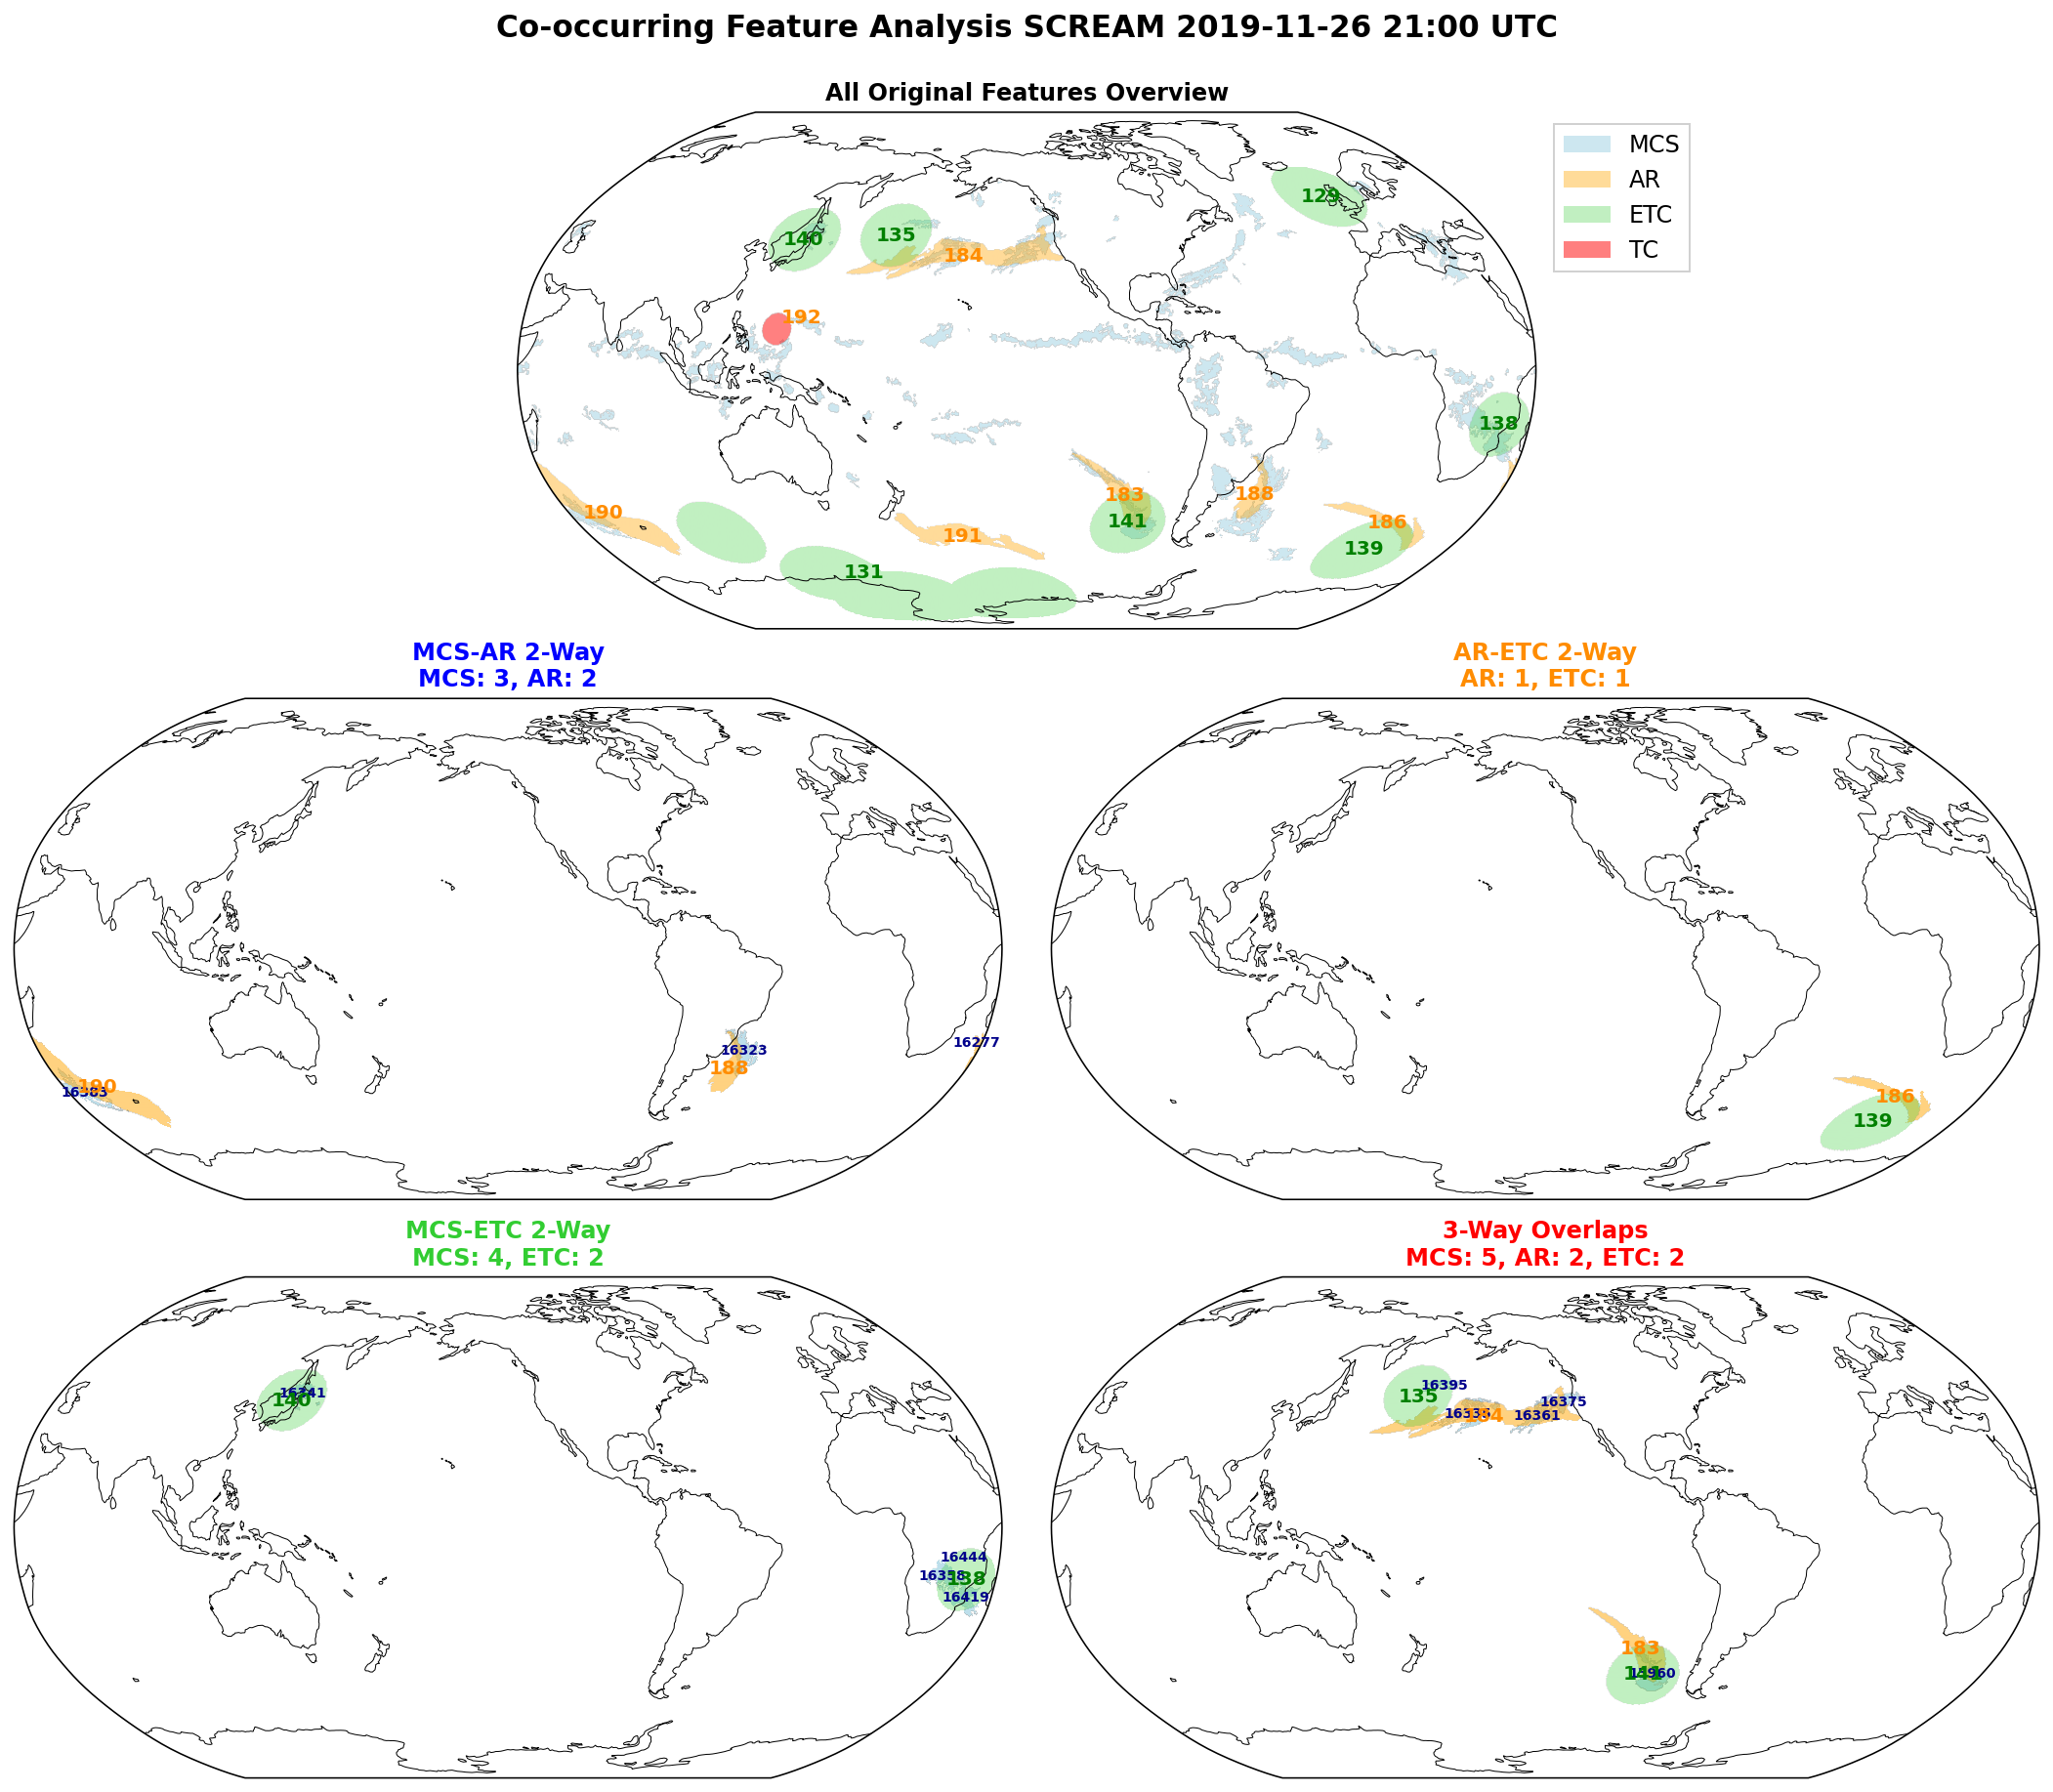


✅ COMPREHENSIVE 5-PANEL VISUALIZATION COMPLETE!
Figure saved as: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_comprehensive_5panel_20191126_2100.png

Visualization includes:
  📍 Top panel: All original features with AR & ETC track IDs
  📊 Bottom panels: 4 types of overlap analysis
    - MCS-AR 2-way pairs: 3 pairs
    - AR-ETC 2-way pairs: 1 pairs
    - MCS-ETC 2-way pairs: 4 pairs
    - 3-way overlaps: 5 MCS, 2 AR, 2 ETC


In [19]:
# CREATE COMPREHENSIVE 5-PANEL VISUALIZATION
print("🚀 CREATING COMPREHENSIVE 5-PANEL VISUALIZATION")
print("="*55)

time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
datetime_string = _time.dt.strftime('%Y%m%d_%H%M').item()
title_suffix = f"Co-occurring Feature Analysis {source_name.upper()} {time_label}"

# Call the comprehensive visualization function
fig_5panel, save_path_5panel = create_comprehensive_5panel_visualization(
    ds=_ds,
    mcs_ar_pairs_2way=mcs_ar_pairs_2way_only,
    ar_etc_pairs_2way=ar_etc_pairs_2way_only,
    mcs_etc_pairs_2way=mcs_etc_pairs_2way_only,
    mcs_tracks_3way=mcs_tracks_with_ar_etc_overlap,
    ar_tracks_3way=ar_tracks_with_mcs_etc_overlap,
    etc_tracks_3way=etc_tracks_with_mcs_ar_overlap,
    figdir=figdir,
    source_name=source_name,
    datetime_string=datetime_string,
    title_suffix=title_suffix,
)

plt.show()

print(f"\n✅ COMPREHENSIVE 5-PANEL VISUALIZATION COMPLETE!")
print(f"Figure saved as: {save_path_5panel}")
print(f"\nVisualization includes:")
print(f"  📍 Top panel: All original features with AR & ETC track IDs")
print(f"  📊 Bottom panels: 4 types of overlap analysis")
print(f"    - MCS-AR 2-way pairs: {len(mcs_ar_pairs_2way_only)} pairs")
print(f"    - AR-ETC 2-way pairs: {len(ar_etc_pairs_2way_only)} pairs")
print(f"    - MCS-ETC 2-way pairs: {len(mcs_etc_pairs_2way_only)} pairs")
print(f"    - 3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC")